# Análisis exploratorio

In [54]:
# librerías
import sys
from pathlib import Path
# modificamos la ruta de referencia del cuaderno
root=Path.cwd().parent
sys.path.append(str(root/"src"))

# datos
import pandas as pd
import numpy as np
# visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# archivos de configuración
from config import data_path
# sklearn
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
# random forest
from sklearn.ensemble import RandomForestClassifier
# regresión logística
from sklearn.linear_model import LogisticRegression
# métricas del modelo
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)

In [2]:
# importamos los datos
df=pd.read_csv(data_path)
# eliminamos la columna CustomerID
df=df.drop(columns=["CustomerID"])

In [3]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [4]:
# información general de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  Class   690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB


# ¿Cómo se distribuye la variable objetivo?

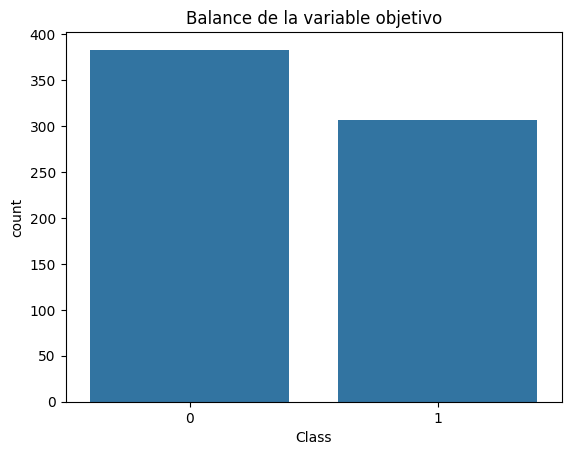

In [5]:
# balance de la clase objetivo
fig=sns.countplot(data=df, x="Class")
fig.set_title("Balance de la variable objetivo")

plt.show()

# Variables categóricas

In [6]:
# obtenemos las columnas categóricas (int64) y las numéricas (float64)
cat_cols=[]
num_cols=[]
for col in df.columns:
    if df[col].dtypes=="int64":
        cat_cols.append(col)
    elif df[col].dtypes=="float64":
        num_cols.append(col)

Las columnas categróricas de esta base de datos son:

In [7]:
print(f" Número de variables categóricas: {len(cat_cols)}")
print(cat_cols)

 Número de variables categóricas: 12
['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'Class']


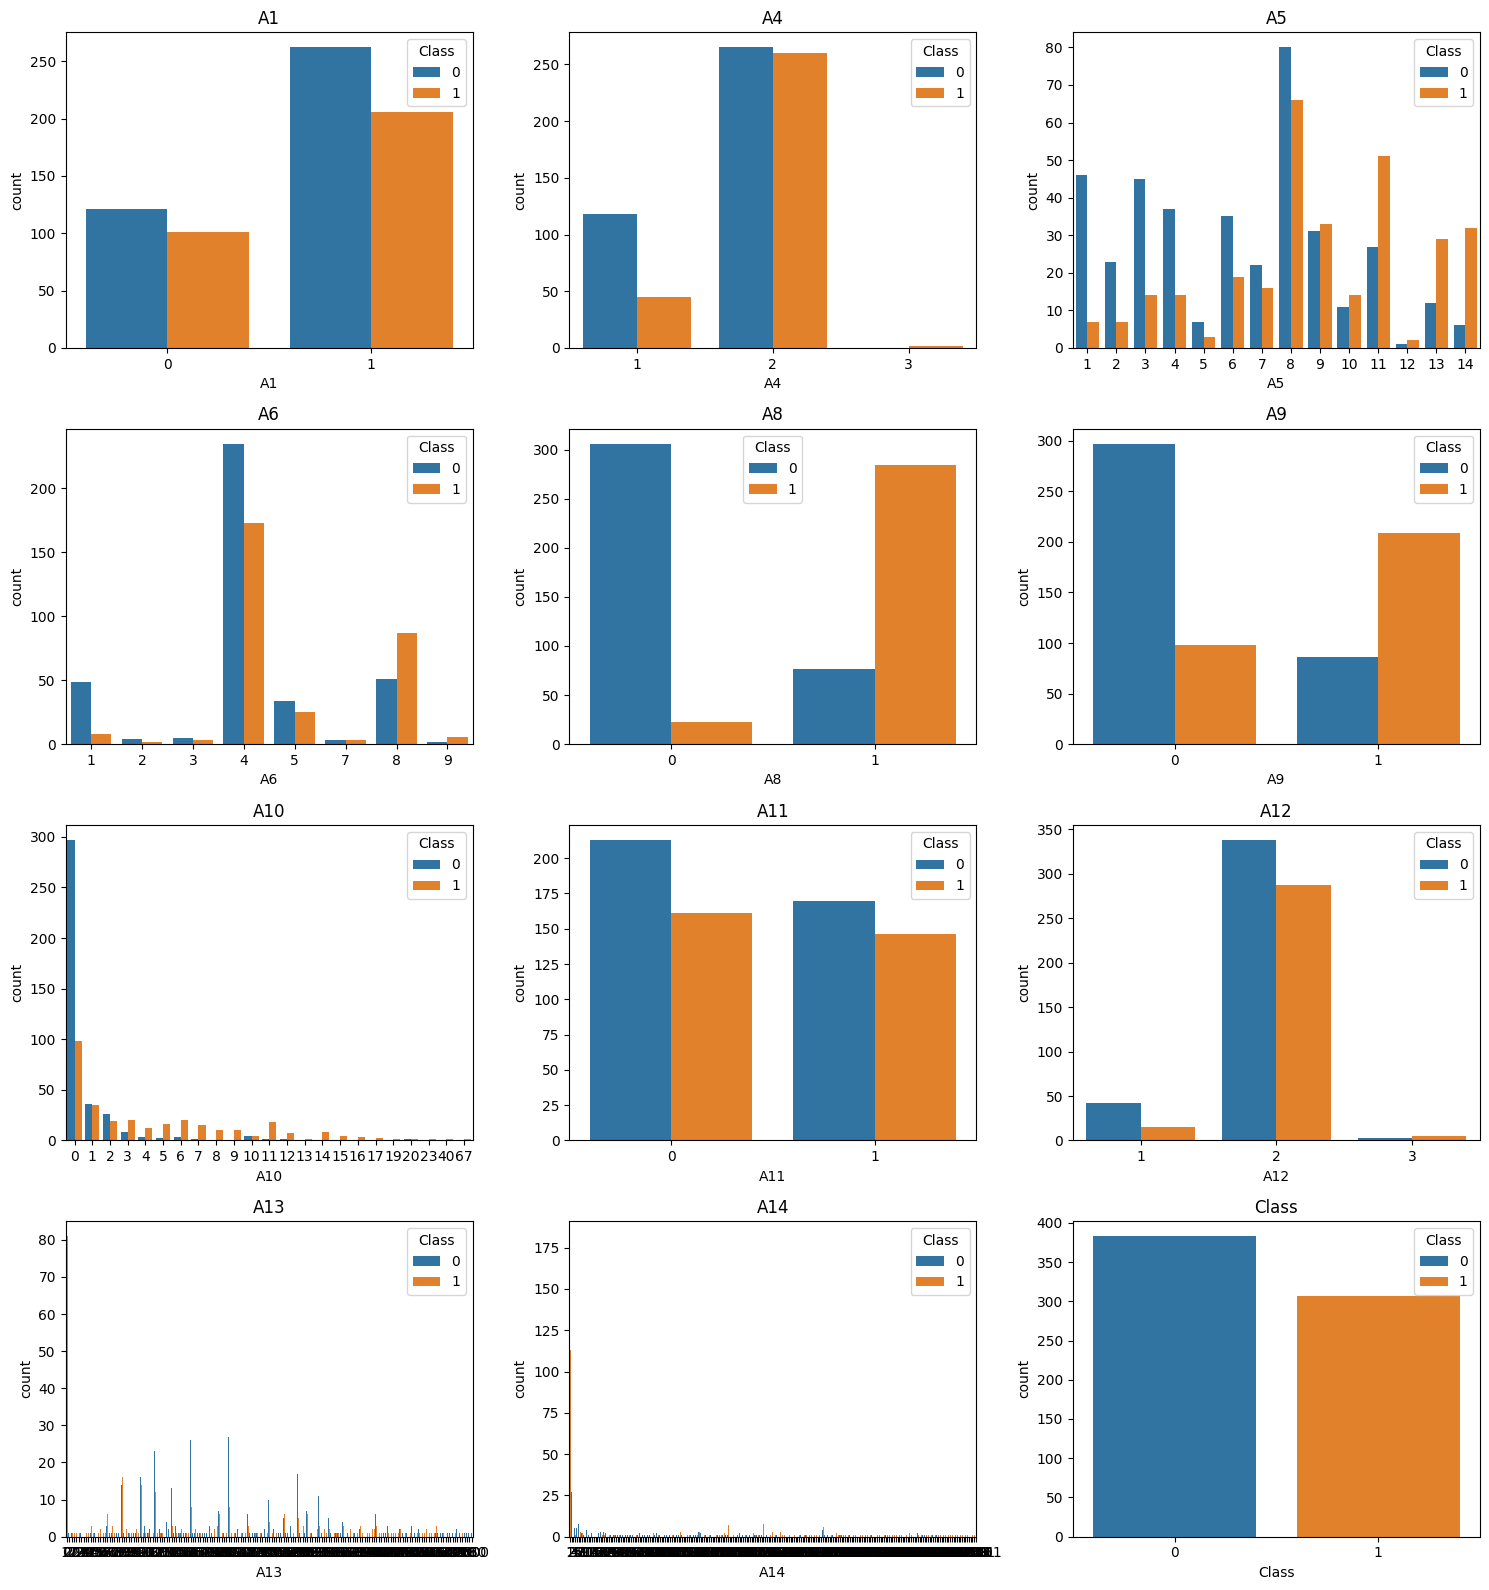

In [8]:
# analicemos las columnas categóricas
n=len(cat_cols)

# columnas de subplots
ncols=3
nrows=int(np.ceil(n/ncols))

fig, axes=plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes=axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df[cat_cols], x=col, ax=axes[i], hue="Class")
    axes[i].set_title(col)
    

plt.tight_layout()
plt.show()

- Las variables A13 A14 tienen una distribución amplia y no uniforme de valores, es conveniente analizarlas por separado.
- A1, A4, A5, A10 y A12 se encuentran desbalanceadas.

## Las columnas A13 y A14

In [9]:
# analiando los valores de las columnas A13 y A14

# función que devuelve la cantidad de valores distintos de una columna categórica
def num_valores_distintos(df, column):
    size=df[column].value_counts().shape
    print(f"La columna {column} tiene {size[0]} valores distintos")

num_valores_distintos(df, "A13")
num_valores_distintos(df, "A14")

La columna A13 tiene 171 valores distintos
La columna A14 tiene 240 valores distintos


Estas columnas tienen una alta cardinalidad.

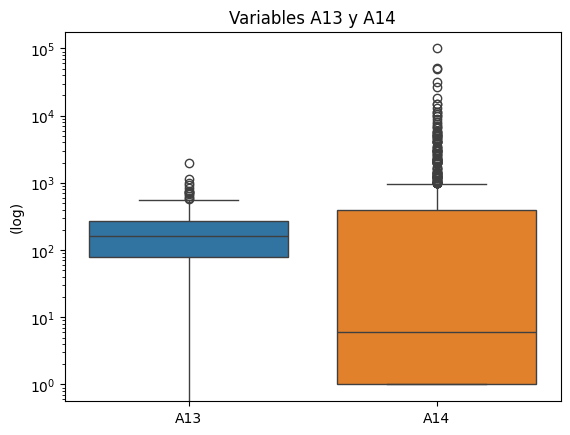

In [10]:
sns.boxplot(data=df[["A13", "A14"]])
plt.yscale("log")
plt.title("Variables A13 y A14")
plt.ylabel("(log)")

plt.show()

- Hay una presencia importante de valores atípicos, especialmente en A14.
- Los valores de A14 están muy dispersos respecto a la mediana, por otro lado A13 tiene una distribución más concentrada.


## Caso A13

In [11]:
A13_column=df["A13"].value_counts().reset_index().sort_values(by="count", ascending=False)
# msotramos el top 5 de frecuencias
print(A13_column.head(5))
# mostramos una descripción general de estos valores
A13_column["count"].describe()

   A13  count
0    0    132
1  200     35
2  120     35
3  160     34
4  100     30


count    171.000000
mean       4.035088
std       11.576292
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      132.000000
Name: count, dtype: float64

- El valor con mayor frecuencia en A13 es "0" con 132 apariciones. Las medidas de tendencia central indican que los valores están muy dispersos, con una desviación estándar de 11.5 respecto a la media.
- La frecuencia media de estos datos es de 1 aparición.

## Caso A14

In [12]:
A14_column=df["A14"].value_counts().reset_index().sort_values(by="count", ascending=False)
print(A14_column.head(5))
# descripción general de los datos
A14_column["count"].describe()

    A14  count
0     1    295
1     2     29
2   501     10
3  1001     10
4     3      9


count    240.000000
mean       2.875000
std       19.074644
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      295.000000
Name: count, dtype: float64

- "1" es el valor con mayor conteo de apariciones en la columna A14, con amplia diferencia entre el segundo y tercer lugar.
- La media se encuentra relativamente cerca de la mediana de los datos pero la desviación estándar es muy grande, lo que implica una dispersión considerable entre los datos.

## ¿Cuál es el la frecuencia mas frecuente entre estas dos columnas?


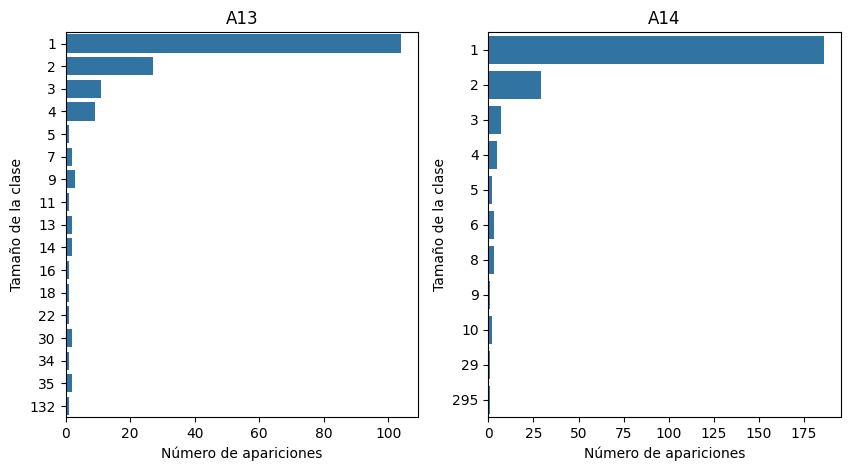

In [13]:
fig, ax=plt.subplots(1,2, figsize=(10,5))
ax.flatten()
sns.countplot(A13_column, y="count", ax=ax[0])
sns.countplot(A14_column, y="count", ax=ax[1])
# ajustes de las gráficas
ax[0].set_title("A13")
ax[0].set_xlabel("Número de apariciones")
ax[0].set_ylabel("Tamaño de la clase")
ax[1].set_title("A14")
ax[1].set_xlabel("Número de apariciones")
ax[1].set_ylabel("Tamaño de la clase")


plt.show()

Este par de gráficas muestra la distribución de las frecuencias de las clases para cada columna. Tras calcular el tamaño de cada clase con `value_counts()`, este gráfico analiza cómo se distribuyen esos tamaños. El objetivo es identificar si los datos están concentrados en unas pocas clases dominantes o si se reparten de manera uniforme.

En ambas columnas se observa casi el mismo comportamiento, el tamaño de clase más frecuente es "1" con amplia diferencia, a partir del tamaño 4, el conteo de las frecuencias disminuye significativamente.

# Variables numéricas

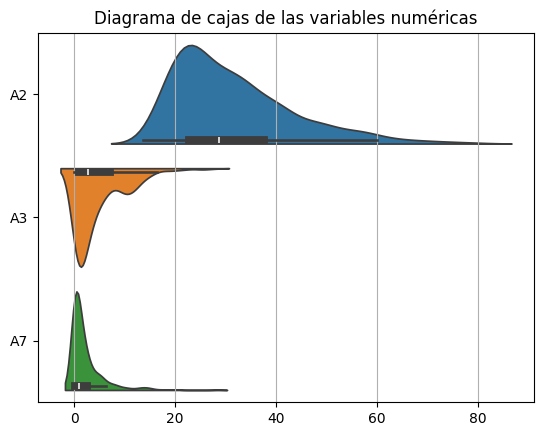

In [14]:
# ahora las variables numéricas
fig=sns.violinplot(df[num_cols], split=True, orient="h")
fig.grid(axis="x")
fig.set_title("Diagrama de cajas de las variables numéricas")
plt.show()

In [15]:
df["A2"].describe()

count    690.000000
mean      31.568203
std       11.853273
min       13.750000
25%       22.670000
50%       28.625000
75%       37.707500
max       80.250000
Name: A2, dtype: float64

In [16]:
df["A3"].describe()

count    690.000000
mean       4.758725
std        4.978163
min        0.000000
25%        1.000000
50%        2.750000
75%        7.207500
max       28.000000
Name: A3, dtype: float64

In [17]:
df["A7"].describe()

count    690.000000
mean       2.223406
std        3.346513
min        0.000000
25%        0.165000
50%        1.000000
75%        2.625000
max       28.500000
Name: A7, dtype: float64

A2

- Distribución marcadamente asimétrica hacia la derecha, con una cola larga hasta valores superiores entre 85 y 90.
- La mayor densidad está concentrada en el rango de 20 a 40.

A3

- Es una distribución con un sesgo positivo más extremo (cola larga a la derecha).
- La caja del grráfico esta comprimida a la izquierda, la mediana está muy cerca de 0.
- La cola larga se extiende alrededor de 30, probablemente sean valores atípicos.
- Cerca de 10 la densidad aumenta ligeramente.

A7

- Una distribución extremadamente sesgada a la derecha, con una media cercana a cero.
- La caja está extremadamente comprimida alrededor de cero, con una mediana cercana.


Análisis general

A3 y A7 tienen colas largas, vale la pena hacer una análisis mas profundo para identifcar si estos valores son atípicos o están codificando alguna característica de la población.

## Mapa de correlaciones

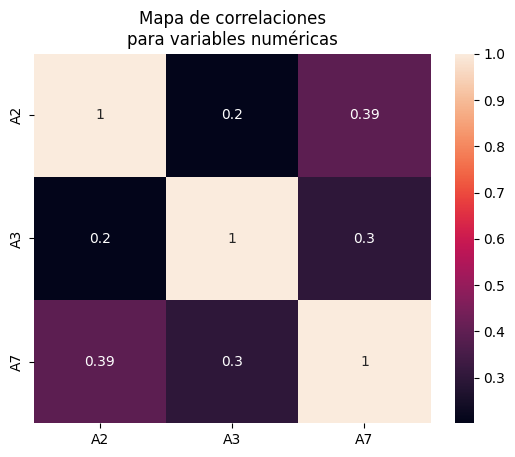

In [18]:
corr=df[num_cols].corr()
fig=sns.heatmap(corr, annot=True)
fig.set_title("Mapa de correlaciones\npara variables numéricas")
plt.show()

No se aprecia correlaciones importantes entre estas variables.

## Relación con la variable objetivo

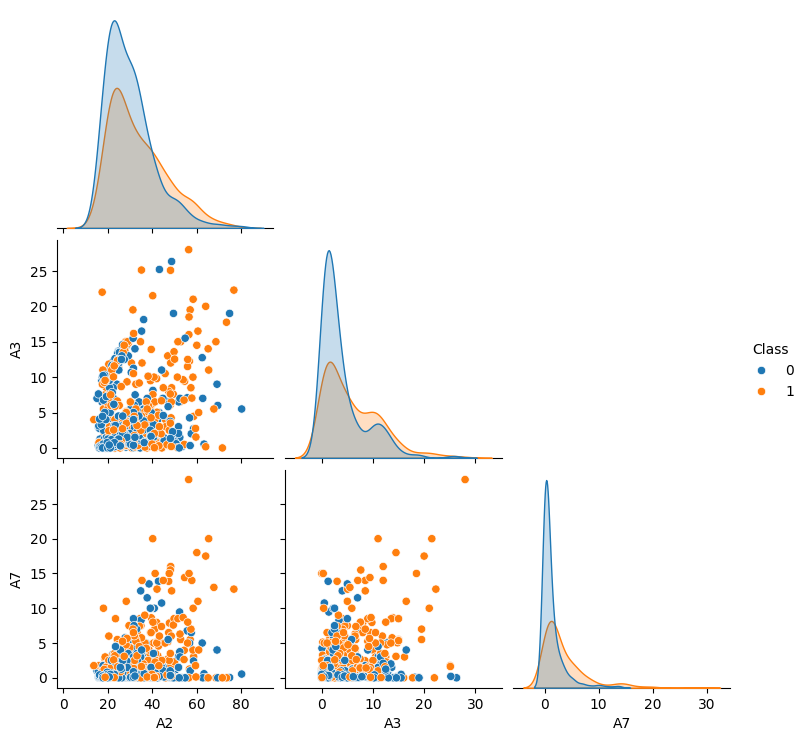

In [19]:
sns.pairplot(
    data=df[num_cols+["Class"]],
    hue="Class",
    corner=True
)
plt.show()

Ninguno de los predictores logra segmentar de forma clara la variable objetivo. En las distribuciones mutuas no se aprecia diferencia entre la clas 0 y 1.

# Conclusiones

- La clase objetivo no presenta un desbalance considerable.
- La base de datos contiene 12 variables categóricas y 3 variables numéricas,
- Los predictores A13 y A14 merecen especial atención ya que tienen alta cardinalidad, A13 con 171 valores distintos y A14 con 240 valores distintos.
  - En A13 el la etiqueta 0 es el que tiene mayor número de apariciones con amplia diferencia.
  - En A14 la etiqueta con mayo frecuencia fue 1.
  - En ambas columnas el tamaño de cada clase más frecuente fue 1, es decir hay más etiquetas que aparecen solo una vez.

# Preparaciónde los datos

In [20]:
# hacemos una copia de los datos 
df_copy=df.copy()

# dividimos el conjunto de datos
X=df.drop(columns=["Class"])
y=df["Class"]
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    train_size=0.7,
    stratify=y,
    random_state=42
)

## Reducción de cardinalidad y escalado
En este conjunto de datos se tienen 5 predictores con alta cardinalidad. Con el objetivo de asegurar un buen rendimiento del modelo predictivo, se hará una codificaión de estas variables usando el módulo `sklearn.preprocessing.TargetEncoder` para reducir la cardinalidad de estos datos.

Los predictores categóricos que serán sometidos a esta transformación son:
- A5
- A6
- A10
- A13
- A14

Escalado:
- A2
- A3
- A4
- A7
- A8
- A9
- A11
- A12

In [21]:
target_columns = ["A5", "A6", "A10", "A13", "A14"]

scale_columns = ["A2", "A3", "A4", "A7", "A8", "A9", "A11", "A12"]

In [22]:
# creamos el preprocessor
preprocessor=ColumnTransformer(
    transformers=[
        ("target_encoder", TargetEncoder(random_state=42), target_columns),
        ("scaler", StandardScaler(), scale_columns),
    ],
    remainder="passthrough"
)

# aplicamos
preprocessor.fit_transform(X_train, y_train)

# transformamos los datos
X_train_prepared=preprocessor.transform(X_train)
X_test_prepared=preprocessor.transform(X_test)

## Rregresión logística

In [23]:
# instancia del modelo
log_reg_model=LogisticRegression(
    max_iter=1000,
    random_state=42
)
# entrenamos
log_reg_model.fit(X_train_prepared, y_train)

# hacemos las predicciones
y_pred=log_reg_model.predict(X_test_prepared)

# las probabilidades
y_prob=log_reg_model.predict_proba(X_test_prepared)[:,1]

In [24]:
print(log_reg_model)
print(classification_report(y_test, y_pred))

LogisticRegression(max_iter=1000, random_state=42)
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       115
           1       0.77      0.81      0.79        93

    accuracy                           0.80       208
   macro avg       0.80      0.80      0.80       208
weighted avg       0.80      0.80      0.80       208



In [25]:
def plot_matrix_confusion(y_test, y_pred, model):
    M=confusion_matrix(y_test, y_pred)
    fig=ConfusionMatrixDisplay(M)
    fig.plot()
    plt.title(f"Matriz de confusión\n{model}")
    plt.show()

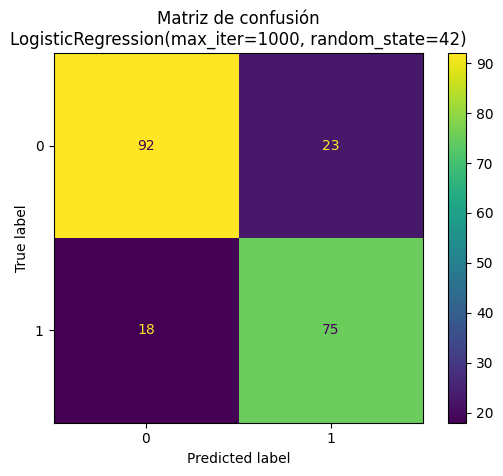

In [26]:
plot_matrix_confusion(y_test, y_pred, log_reg_model)

In [39]:
def plot_roc_curve(y_test, y_prob, model):
    fpr, tpr, thresholds=roc_curve(y_test, y_prob)
    roc_score=roc_auc_score(y_test,y_prob)
    print(f"ROC AUC Score={roc_score}\nMODELO: {model}")
    plt.plot(fpr, tpr, label="Modelo")
    plt.title(f"Curva ROC\n{model}")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    # diagonal
    plt.plot([0,1], [0,1], color="red", linestyle="--", label="Random classifier")
    plt.legend()
    plt.plot()

ROC AUC Score=0.8739597942964002
MODELO: LogisticRegression(max_iter=1000, random_state=42)


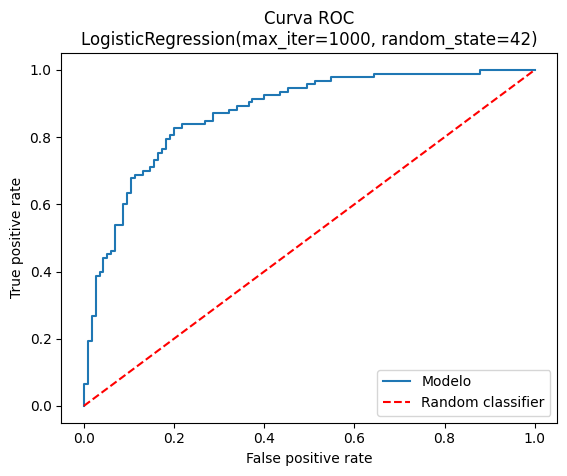

In [40]:
plot_roc_curve(y_test, y_prob, log_reg_model)

### Optimización de la regresión logística

In [49]:
# instancia del modelo base
lr=LogisticRegression(
    random_state=42,
    max_iter=1000
)

# definimos el espacio de búsqueda
param_grid=[
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100]
    },
     {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100]
    }
]

# creamos la rejilla de búsqueda
grid_lr=GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [50]:
# entrenamiento de la búsqueda
grid_lr.fit(X_train_prepared, y_train)

# mostramos los mejores parámetros
grid_lr.best_params_

Fitting 5 folds for each of 15 candidates, totalling 75 fits


{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [51]:
# mejor rendimiento
grid_lr.best_score_

0.922748753909393

In [52]:
# obtenemos el mejor estimador
best_lr=grid_lr.best_estimator_

# obtenemos las predicciones
y_pred_best_lr=best_lr.predict(X_test_prepared)

# reporte de clasificaión
print(classification_report(y_test, y_pred_best_lr))

              precision    recall  f1-score   support

           0       0.80      0.75      0.77       115
           1       0.71      0.76      0.74        93

    accuracy                           0.75       208
   macro avg       0.75      0.76      0.75       208
weighted avg       0.76      0.75      0.76       208



Se realizó una búsqueda de hiperparámetros mediante GridSearchCV. Aunque la validación cruzada obtuvo un F1 promedio de 0.923 con solver='liblinear', penalty='l1' y C=1, el modelo optimizado obtuvo un desempeño inferior en el conjunto de prueba respecto al modelo base. Por ello se seleccionó el modelo base por su mejor capacidad de generalización.

## Random forest

In [42]:
# instancia del modelo
RF_model=RandomForestClassifier()
# entrenamos
RF_model.fit(X_train_prepared, y_train)

# hacemos las predicciones
y_pred_rf=RF_model.predict(X_test_prepared)

# obtenemos las probabilidades
y_prob_rf=RF_model.predict_proba(X_test_prepared)[:,1]

In [47]:
print(RF_model)
print(classification_report(y_test, y_pred_rf))


RandomForestClassifier()
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       115
           1       0.72      0.76      0.74        93

    accuracy                           0.76       208
   macro avg       0.76      0.76      0.76       208
weighted avg       0.77      0.76      0.76       208



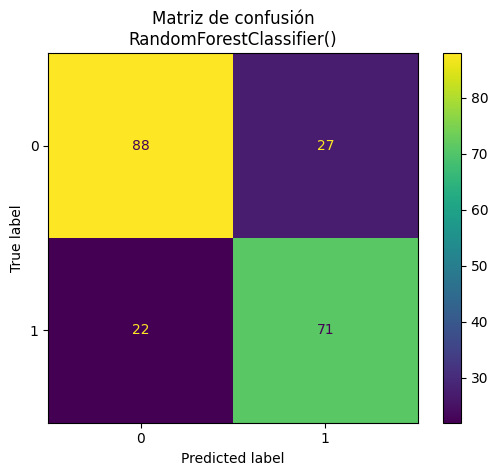

In [45]:
plot_matrix_confusion(y_test, y_pred_rf, RF_model)

ROC AUC Score=0.8869565217391304
MODELO: RandomForestClassifier()


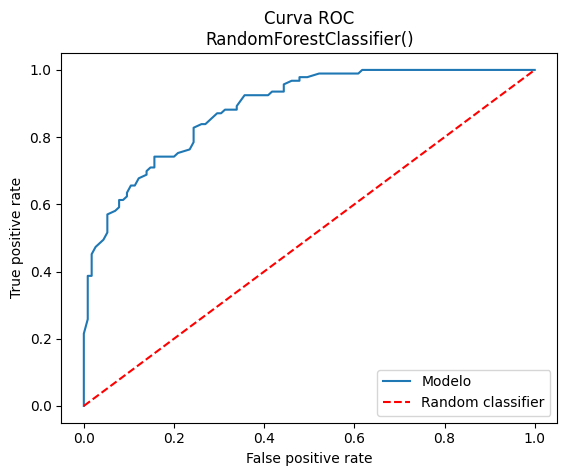

In [46]:
plot_roc_curve(y_test, y_prob_rf, RF_model)

### Optimización de Random Forest
Para optimizar el bosque aleatorio se usará `RandomizedSearchCV()` ya que es óptimo para este tipo de clasificador.

In [64]:
# instancia del modelo base
rf=RandomForestClassifier(
    random_state=42
)

# conjunto de parámetros
param_dist={
    "n_estimators": [100,200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features":["sqrt", "log2"],
    "bootstrap": [True, False]
}

# creamos el la búsqueda aleatoria
random_search=RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [65]:
# entrenamos
random_search.fit(X_train_prepared, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [66]:
# mejor modelo
random_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20,
 'bootstrap': False}

In [67]:
# mejor puntaje
random_search.best_score_

0.9475548268087722

In [68]:
# evaluamos 
best_rf=random_search.best_estimator_

# hacemos las predicciones
y_pred_best_rf=best_rf.predict(X_test_prepared)

print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       115
           1       0.73      0.80      0.76        93

    accuracy                           0.77       208
   macro avg       0.77      0.78      0.77       208
weighted avg       0.78      0.77      0.77       208



Se evaluó un modelo de Random Forest utilizando tanto la configuración por defecto como una optimizada mediante RandomizedSearchCV. La optimización mejoró el desempeño del modelo, especialmente en la recuperación de la clase positiva (recall), pasando de 0.76 a 0.80. Sin embargo, al compararlo con la regresión logística, esta última obtuvo mejores métricas generales sobre el conjunto de prueba, alcanzando un F1-score de 0.79 frente a 0.76 del Random Forest optimizado. Por ello, se seleccionó la regresión logística como modelo final.